
# Ejercicio de evaluación "Exploración de Datos"
### Rodrigo Jafet Osorio Angeles No. Cta: 318008893

Con base en la información compartida en clase, realizar los siguientes pasos al analizar las variables restantes:
1. language
2. country
3. actors (separarlo)texto en cursiva
4. imdb_score
5. movie_facebook_likes

Además, si se observan:

1. Datos que son outliers deberán limpiarlos!
2. Columnas con poca utilidad podrán borrarlas!



In [ ]:
# Importamos las librerías necesarias para el análisis de datos y visualización

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga y limpieza de datos

imdb = pd.read_csv('data/IMDB.csv') 
print("Tamaño del dataset en filas y columnas:", imdb.shape)

Tamaño del dataset en filas y columnas: (97, 13)


In [3]:
# Identificar las columnas con poca utilidad
imdb.columns 

Index(['color', 'director_name', 'duration', 'gross', 'genres', 'movie_title',
       'title_year', 'language', 'country', 'budget', 'imdb_score', 'actors',
       'movie_facebook_likes'],
      dtype='str')

In [4]:
# Eliminamos columnas innecesarias
imdb.drop(['color','director_name','duration','gross','genres','title_year','budget'], axis=1, inplace=True)

In [5]:
# Eliminamos filas duplicadas 
imdb[imdb.duplicated(keep=False)]

imdb2 = imdb.copy()
imdb2.drop_duplicates(inplace=True)
print("Tamaño del dataset después de eliminar duplicados en filas y columnas:", imdb2.shape)

Tamaño del dataset después de eliminar duplicados en filas y columnas: (91, 6)


# Variable Language
1. Analizar valores nulos
2. Detección de Outliers
3. Tipo de dato de la variable

In [6]:
nulos_inicial = imdb2 ['language'].isnull().sum()
print("Número de valores nulos en la columna 'language' antes de eliminar:", nulos_inicial)

Número de valores nulos en la columna 'language' antes de eliminar: 0


In [7]:
valores = imdb2 ['language'].count()
print("Número de valores en la columna 'language':", valores)

Número de valores en la columna 'language': 91


In [8]:

print("idiomas únicos:", imdb2['language'].nunique())
print("idioma más común:", imdb2['language'].mode()[0])

idiomas únicos: 1
idioma más común: English


In [9]:
print("Tipo de dato general de la columna:", imdb2['language'].dtype)

Tipo de dato general de la columna: str


# Variable country 
1. Analizar valores nulos
2. Detección de Outliers
3. Tipo de dato de la variable
4. Limpieza de datos 
5. Gráfico de países de la película


In [10]:
print("Tipo de dato de la columna 'Country':", imdb2['country'].dtype)

Tipo de dato de la columna 'Country': str


In [11]:
nulos_country = imdb2 ['country'].isnull().sum()
print("Número de valores nulos en la columna 'country' antes de eliminar:", nulos_country)

Número de valores nulos en la columna 'country' antes de eliminar: 0


In [12]:
print("Países únicos:", imdb2['country'].nunique())
print("País más común:", imdb2['country'].mode()[0])

Países únicos: 12
País más común: USA


In [ ]:
# Visualizar datos de países 
print("--- Países antes de la limpieza ---")
print(imdb2['country'].value_counts())

--- Países antes de la limpieza ---
country
USA               72
UK                 6
usa                3
France             2
Germany            1
New Zealand        1
India              1
United States      1
Australia          1
Czech Republic     1
Kyrgyzstan         1
Canada             1
Name: count, dtype: int64


In [14]:
# Quitamos espacios en blanco y convertimos a mayúsculas
imdb2['country'] = imdb2['country'].str.strip().str.upper()

In [16]:
# Mapeo por diccionario
diccionario_paises = {
    'UNITED STATES': 'USA',
    'UNITED KINGDOM': 'UK',
    'ENGLAND': 'UK' 
}

In [17]:
imdb2['country'] = imdb2['country'].replace(diccionario_paises)

print("\n--- Países después de la limpieza ---")
print(imdb2['country'].value_counts())


--- Países después de la limpieza ---
country
USA               76
UK                 6
FRANCE             2
GERMANY            1
NEW ZEALAND        1
INDIA              1
AUSTRALIA          1
CZECH REPUBLIC     1
KYRGYZSTAN         1
CANADA             1
Name: count, dtype: int64


In [18]:
# Volvemos a revisar los tipos de datos para asegurarnos de que todo esté correcto
print("Países únicos:", imdb2['country'].nunique())
print("País más común:", imdb2['country'].mode()[0])

Países únicos: 10
País más común: USA


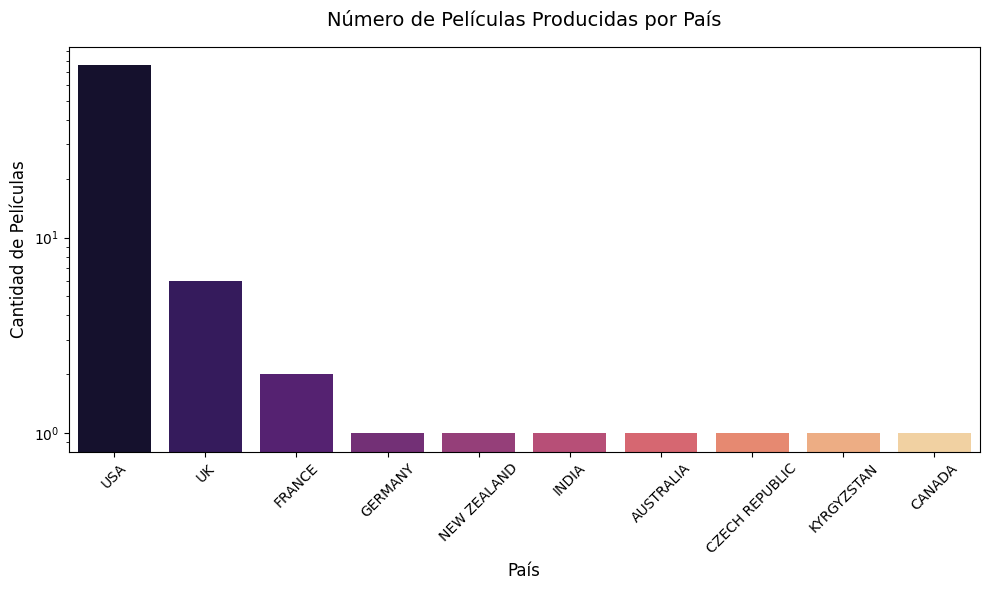

In [20]:
# Gráfico de barras para visualizar la distribución de países
plt.figure(figsize=(10, 6))
conteo_paises = imdb2['country'].value_counts()

sns.barplot(x=conteo_paises.index, y=conteo_paises.values, hue=conteo_paises.index, palette='magma', legend=False)

plt.title('Número de Películas Producidas por País', fontsize=14, pad=15)
plt.xlabel('País', fontsize=12)
plt.ylabel('Cantidad de Películas', fontsize=12)

plt.xticks(rotation=45) 

plt.yscale('log')
plt.tight_layout()
plt.show()

# Variable actors (separarlo) texto en cursiva
1. Analizar valores nulos
2. Detección de Outliers
3. Tipo de dato de la variable
4. Limpieza de datos 
5. Separar texto
6. Texto en cursivas
7. Gráfica para actores más frecuentes

In [21]:
# Tipo de dato
print("Tipo de dato de la columna 'Actors':", imdb2['actors'].dtype)

Tipo de dato de la columna 'Actors': str


In [23]:
nulos_act = imdb2 ['actors'].isnull().sum()
print("Número de valores nulos en la columna 'Actors' antes de eliminar:", nulos_act)

Número de valores nulos en la columna 'Actors' antes de eliminar: 0


In [24]:
# Limpieza de datos con expresiones regulares regex 
# Mantener solo letras, números, espacios, comas, puntos y guiones.
# Cualquier otro símbolo extraño (como emojis o signos raros) será eliminado.
imdb2['actors'] = imdb2['actors'].str.replace(r'[^\w\s,.-]', '', regex=True)


In [26]:
# Separar los actores en listas
# .str.split() busca la coma y expand=True obliga a Pandas a crear una columna nueva por cada separación
imdb2_actores = imdb2['actors'].str.split(',', expand=True)
imdb2_actores.columns = [f'Actor_{i+1}' for i in range(imdb2_actores.shape[1])]

In [27]:
# Convertir texto a cursiva (Formato Markdown)
# Si la celda no está vacía (pd.notna), le quitamos espacios extra (.strip()) 
# y la envolvemos entre asteriscos para representarla en cursiva.
for col in imdb2_actores.columns:
    imdb2_actores[col] = imdb2_actores[col].apply(
        lambda x: f"*{str(x).strip()}*" if pd.notna(x) and str(x).strip() != "" else x
    )

# Unimos las nuevas columnas limpias a nuestro DataFrame copia
imdb2 = pd.concat([imdb2, imdb2_actores], axis=1)

# Eliminamos la columna original 'actors' para no tener datos redundantes
imdb2 = imdb2.drop(columns=['actors'])

In [28]:
print("--- Separación y formato ---")
display(imdb2[[col for col in imdb2.columns if 'Actor_' in col]].head())

--- Separación y formato ---


,Actor_1,Actor_2,Actor_3
0,*Leonardo DiCaprio*,*Matthew McConaughey*,*Jon Favreau*
1,*Robert Downey Jr.*,*Jon Favreau*,*Don Cheadle*
2,*Craig Stark*,*Jennifer Jason Leigh*,*Zoë Bell*
3,*Matt Damon*,*Kieran Culkin*,*John Gallagher Jr.*
4,*Aidan Turner*,*Adam Brown*,*James Nesbitt*


In [32]:
# gráfico de barras para visualizar los actores más frecuentes
columnas_actores = [col for col in imdb2.columns if 'Actor_' in col]

# Apilar todas las columnas en una sola serie vertical continua (.stack())
todos_los_actores = imdb2[columnas_actores].stack().reset_index(drop=True)

actores_limpios = todos_los_actores.str.replace('*', '', regex=False).str.strip()

actores_limpios = actores_limpios[actores_limpios != '']
actores_limpios = actores_limpios.dropna()

In [33]:
top_actores = actores_limpios.value_counts().head(15)

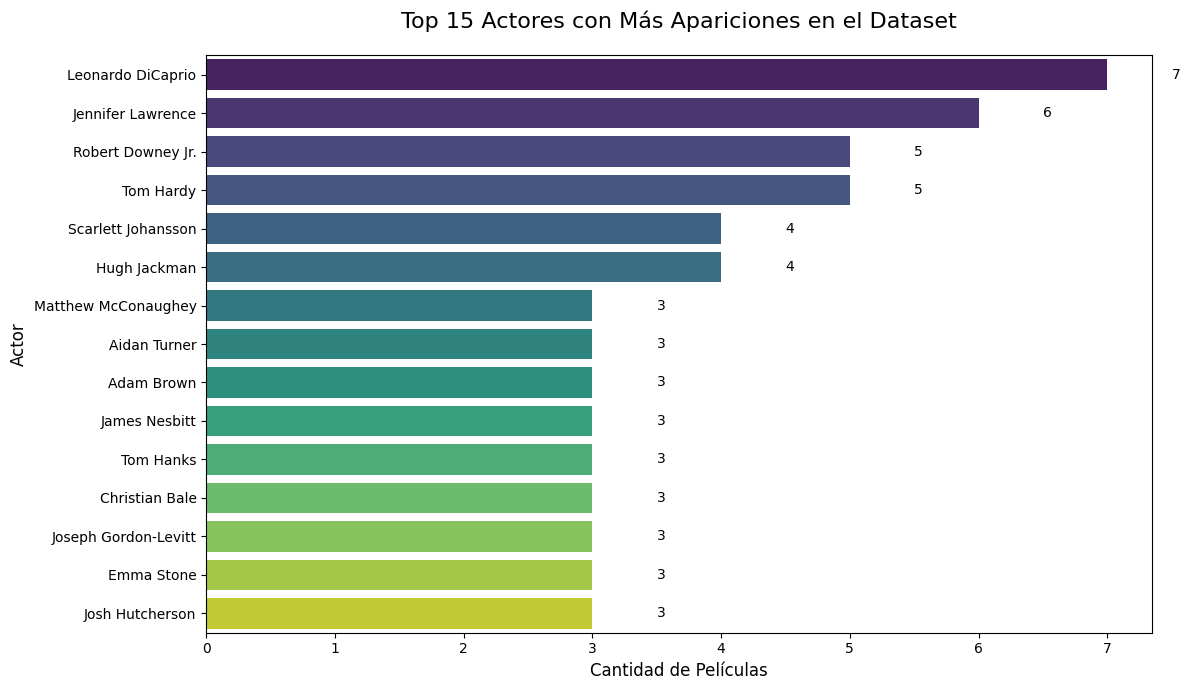

In [34]:
# Usamos y=index y x=values para que las barras sean horizontales
plt.figure(figsize=(12, 7))

sns.barplot(x=top_actores.values, y=top_actores.index, 
            hue=top_actores.index, palette='viridis', legend=False)

plt.title('Top 15 Actores con Más Apariciones en el Dataset', fontsize=16, pad=20)
plt.xlabel('Cantidad de Películas', fontsize=12)
plt.ylabel('Actor', fontsize=12)

# Añadir el número exacto al final de cada barra
for index, value in enumerate(top_actores.values):
    plt.text(value + 0.5, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Variable imdb_score
1. Analizar valores nulos
2. Detección de Outliers
3. Tipo de dato de la variable
4. Limpieza de datos redondear datos y valores positivos
5. Gráfico para mejores péliculas

In [36]:
nulos_score = imdb2 ['imdb_score'].isnull().sum()
print("Número de valores nulos en la columna 'Score' antes de eliminar:", nulos_score)

Número de valores nulos en la columna 'Score' antes de eliminar: 0


In [37]:
print("Tipo de dato de la columna 'Score':", imdb2['imdb_score'].dtype)

Tipo de dato de la columna 'Score': float64


In [38]:
# Garantizar que todos los valores sean positivos usando el valor absoluto (.abs()) y redondear 
imdb2['imdb_score'] = imdb2['imdb_score'].abs()
imdb2['imdb_score'] = imdb2['imdb_score'].round(1)

In [39]:
print("--- Transformación de IMDB Score ---")
display(imdb2[['movie_title', 'imdb_score']].head())

--- Transformación de IMDB Score ---


,movie_title,imdb_score
0,The Wolf of Wall Street,8.2
1,Iron Man 3,7.2
2,The Hateful Eight,7.9
3,Margaret,6.5
4,The Hobbit: The Desolation of Smaug,7.9


In [40]:
# Eliminamos películas duplicadas
# Ordenamos de mayor a menor y nos quedamos con las 15 primeras
top_peliculas = imdb2[['movie_title', 'imdb_score']].drop_duplicates(subset='movie_title')
top_peliculas = top_peliculas.sort_values(by='imdb_score', ascending=False).head(15)


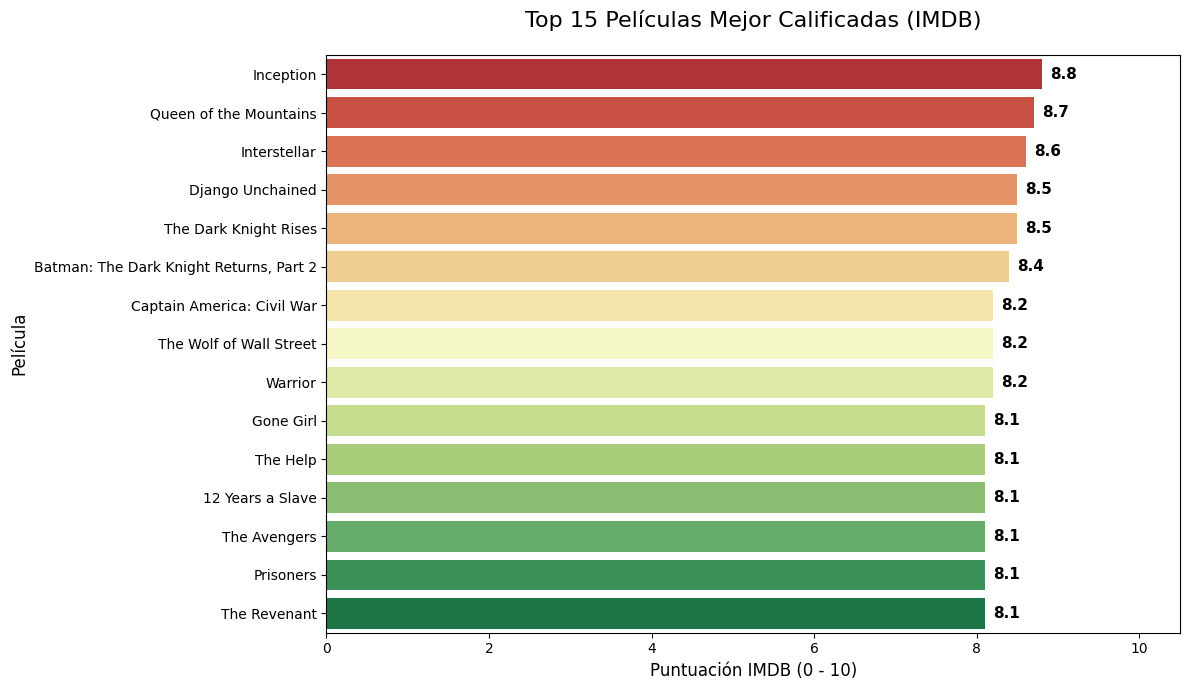

In [41]:
# Gráfico para visualizar las películas mejor calificadas
plt.figure(figsize=(12, 7))

sns.barplot(x=top_peliculas['imdb_score'], y=top_peliculas['movie_title'], 
            hue=top_peliculas['movie_title'], palette='RdYlGn', legend=False)

plt.title('Top 15 Películas Mejor Calificadas (IMDB)', fontsize=16, pad=20)
plt.xlabel('Puntuación IMDB (0 - 10)', fontsize=12)
plt.ylabel('Película', fontsize=12)

# Límite del eje X de 0 a 10
plt.xlim(0, 10.5)

for index, value in enumerate(top_peliculas['imdb_score']):
    plt.text(value + 0.1, index, str(value), va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Variable movie_facebook_likes
1. Analizar valores nulos
2. Detección de Outliers
3. Tipo de dato de la variable
4. Limpieza de datos redondear datos y valores positivos

In [42]:
nulos_likes = imdb2 ['movie_facebook_likes'].isnull().sum()
print("Número de valores nulos en la columna 'movie_facebook_likes' antes de eliminar:", nulos_likes)

Número de valores nulos en la columna 'movie_facebook_likes' antes de eliminar: 0


In [43]:
print("Tipo de dato de la columna 'movie_facebook_likes':", imdb2['movie_facebook_likes'].dtype)

Tipo de dato de la columna 'movie_facebook_likes': int64


In [45]:
# Aplicamos valor absoluto para valores enteros
imdb2['movie_facebook_likes'] = imdb2['movie_facebook_likes'].abs()

# Filtramos el DataFrame para quedarnos los que tienen más de 0 likes
registros_antes = len(imdb2)
imdb2 = imdb2[imdb2['movie_facebook_likes'] > 0]
registros_despues = len(imdb2)

print(f"Limpieza completada: Se descartaron {registros_antes - registros_despues} películas que tenían 0 likes.")
display(imdb2[['movie_title', 'movie_facebook_likes']].head())

Limpieza completada: Se descartaron 0 películas que tenían 0 likes.


,movie_title,movie_facebook_likes
0,The Wolf of Wall Street,138000
1,Iron Man 3,95000
2,The Hateful Eight,114000
4,The Hobbit: The Desolation of Smaug,83000
5,Batman v Superman: Dawn of Justice,197000


In [46]:
# Eliminamos películas duplicadas por título y sacamos el Top
top_likes = imdb2[['movie_title', 'movie_facebook_likes']].drop_duplicates(subset='movie_title')
top_likes = top_likes.sort_values(by='movie_facebook_likes', ascending=False).head(15)

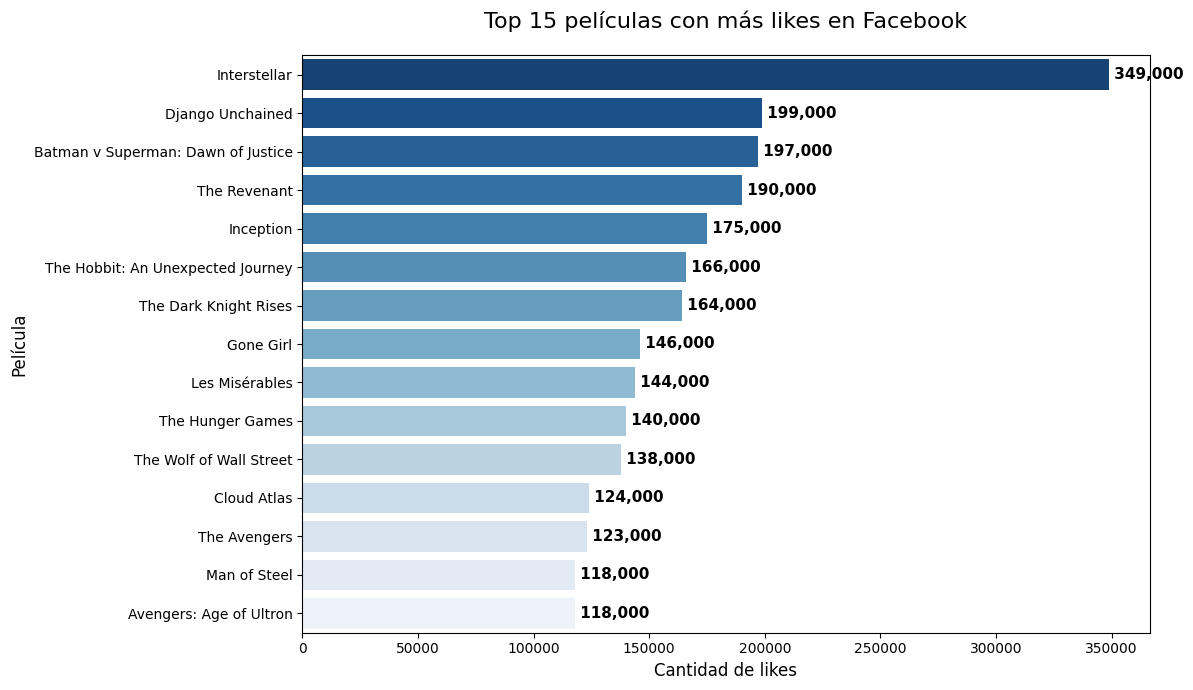

In [47]:
# Creamos el gráfico para visualizar las películas con más likes en Facebook
plt.figure(figsize=(12, 7))

sns.barplot(x=top_likes['movie_facebook_likes'], y=top_likes['movie_title'], 
            hue=top_likes['movie_title'], palette='Blues_r', legend=False)

plt.title('Top 15 películas con más likes en Facebook', fontsize=16, pad=20)
plt.xlabel('Cantidad de likes', fontsize=12)
plt.ylabel('Película', fontsize=12)

# Usamos f"{int(value):,}" para que ponga comas separadoras de miles
for index, value in enumerate(top_likes['movie_facebook_likes']):
    plt.text(value, index, f" {int(value):,}", va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()